In [1]:
# Imports
import glob
import os
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, make_scorer, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [2]:
# Constants
GENERAL_DESCRIPTORS = {"Time", "RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}
BIOMETRICS = GENERAL_DESCRIPTORS - {"Time", "ICUType"}

In [3]:
# Function to clean individual Patient Data
def clean_patient_data(patient_file):
    """
    Cleans a single patient's data.

    Args:
        patient_file (str): The path to the patient's data file.

    Returns:
        pd.DataFrame: The cleaned patient time series with columns:
        RecordID, Time, and one column per vital sign.
    """
    df = pd.read_csv(patient_file)

    # Clean time into minutes since.
    def to_minutes(time_str):
        h, m = map(int, time_str.split(':'))
        return h * 60 + m

    df["Time"] = df["Time"].apply(to_minutes)

    # Extract RecordID and remove it. We'll convert it into its own column.
    recordid = df.loc[df["Parameter"] == "RecordID", "Value"].values[0]
    df = df[df["Parameter"] != "RecordID"]

    # Pivot the data to have parameters as columns and timestamps as rows
    df = df.pivot_table(index="Time", columns="Parameter",
                        values="Value", aggfunc='mean')

    # Per dataset description. -1 means it is missing value
    df = df.mask(df == -1)
    patient_means = df.mean(axis=0, skipna=True)
    df = df.fillna(patient_means)

    # Flatten to a tidy table for concatenation across all patients.
    df = df.reset_index()
    df["RecordID"] = int(recordid)
    return df

In [4]:
# Function to load outcomes/output
def load_outcomes(data_set, data_root):
    """
    Load survival outcomes for the selected dataset.
    -1 survival indicates the patient survived. All other numbers indicate days until death.

    Reads the outcomes file that corresponds to this loader's dataset
    identifier and returns only the columns needed for supervised learning.

    Returns:
        pd.DataFrame: A DataFrame indexed by RecordID containing Risk.
                        Risk is a binary column where 1 indicates risk and 0 indicates
                        no immediate risk.
    """
    outcomes_file_path = os.path.join(
        data_root, "outcomes", f"outcomes-{data_set}.txt")

    # We only care about RecordID and Survival
    df = pd.read_csv(outcomes_file_path, usecols=[
                     "RecordID", "Survival", "In-hospital_death"])
    df["Risk"] = ((df["Survival"] != -1) |
                   (df["In-hospital_death"] == 1)).astype(int)
    df = df.drop(columns=["Survival", "In-hospital_death"])
    return df.set_index("RecordID")

In [5]:
# Function to process dataset.
def process_dataset(data_set, undersample = False):
    """
    Loads and processes the patient data from the specified directory.
    Each set is expected to reside in a directory named
    "set-a", "set-b", or "set-c" under the data directory.
    set-a is the training set, set-b is the test set and set-c is the validation set.

    Args:
        undersample: Whether to apply random undersampling on the majority
            class. This should generally be enabled only for training data.

    Returns:
        (pd.DataFrame, pd.DataFrame): A tuple containing the processed
        patient data and the corresponding outcomes.
        The shape of features is (record_id, vitals..., aggregated_vitals..., risk),
        where each time-varying vital is expanded into four features:
        *_mean, *_median, *_min, and *_max.
        Corresponding outcomes is a DataFrame indexed by RecordID containing risk.
        Risk is a binary column where 1 indicates risk and 0 indicates no immediate risk.
    """
    if data_set not in {"a", "b", "c"}:
        raise ValueError('data_set must be one of "a", "b", or "c"')

    data_root = os.path.abspath(os.path.join("..", "..", "data"))
    dir_path = os.path.join(data_root, f"set-{data_set}")
    fp = glob.glob(os.path.join(dir_path, "*.txt"))
    patient_data = []

    for f in fp:
        patient_data.append(clean_patient_data(f))

    df_all = pd.concat(patient_data, ignore_index=True)

    # Grab all vital columns. Exclude general descriptors.
    vital_columns = [c for c in df_all.columns if c not in GENERAL_DESCRIPTORS]

    # Grab biometric columns, these should not be aggregated
    biometric_columns = [c for c in df_all.columns if c in BIOMETRICS]

    # Fill any remaining missing values using global medians for each vital.
    global_medians = df_all[vital_columns].median()
    df_all[vital_columns] = df_all[vital_columns].fillna(global_medians)

    # Aggregate each vital over time into one row per patient.
    grouped = df_all.groupby("RecordID")[vital_columns]
    df_mean = grouped.mean().add_suffix("_mean")
    df_median = grouped.median().add_suffix("_median")
    df_min = grouped.min().add_suffix("_min")
    df_max = grouped.max().add_suffix("_max")
    df_std = grouped.std(ddof=0).add_suffix("_std")

    # Fill missing biometrics: median for continuous, mode for Gender.
    # Would love to drop it but too many records are missing it.
    continuous_biometrics = [
        c for c in biometric_columns if c not in {"RecordID", "Gender"}]
    bio_medians = df_all[continuous_biometrics].median()
    df_all[continuous_biometrics] = df_all[continuous_biometrics].fillna(
        bio_medians)
    gender_mode = df_all["Gender"].mode()[0]
    df_all["Gender"] = df_all["Gender"].fillna(gender_mode)

    df_features = pd.concat(
        [df_mean, df_median, df_min, df_max, df_std], axis=1)

    # One-hot encode ICUType
    icu_dummies = pd.get_dummies(df_all[["RecordID", "ICUType"]], columns=[
                                 "ICUType"], dummy_na=True)
    icu_dummies = icu_dummies.drop_duplicates(
        subset="RecordID").set_index("RecordID")
    df_features = df_features.join(icu_dummies)

    # Add the biometrics, unaggregated.
    df_features = df_features.join(df_all[biometric_columns].drop_duplicates(
        subset="RecordID").set_index("RecordID"), how="left")

    # Sort columns to guarantee consistent feature order across datasets.
    df_features = df_features[sorted(df_features.columns)]

    outcomes = load_outcomes(data_set, data_root)

    if undersample:
        rus = RandomUnderSampler(sampling_strategy="majority", random_state=42)
        return rus.fit_resample(df_features, outcomes)

    return df_features, outcomes

## Findings on Data
All sets of data are highly imbalanced where there are many more patients that passed as opposed to survived.

To combat this, **Random Under Sampling** is performed on the training data.

In [6]:
# Setup the data
df_x_train, df_y_train = process_dataset(data_set="a", undersample=True)
df_x_test, df_y_test = process_dataset(data_set="b", undersample=False)
df_x_val, df_y_val = process_dataset(data_set="c", undersample=True)

# Scale the data using Z-Score normalization.
scaler = StandardScaler()
# Train on both train and validation sets. GridSearch was already used to find best hyperparameters.
x_train_scaled = scaler.fit_transform(pd.concat([df_x_train, df_x_val]))
x_test_scaled = scaler.transform(df_x_test)

y_train = pd.concat([df_y_train, df_y_val]).values.ravel()
y_test = df_y_test.values.ravel()

# Dimensions of the data
print(f"Training set: {x_train_scaled.shape}, {y_train.shape}")
print(f"Test set: {x_test_scaled.shape}, {y_test.shape}")

Training set: (6146, 189), (6146,)
Test set: (4000, 189), (4000,)


## Logistic Regression
In here we are training a model using LogisticRegression algorithm. 

The hyperparameters used here are the best parameters found after tuning using GridSearchCV.

              precision    recall  f1-score   support

           0       0.82      0.73      0.77      2483
           1       0.63      0.74      0.68      1517

    accuracy                           0.73      4000
   macro avg       0.73      0.74      0.73      4000
weighted avg       0.75      0.73      0.74      4000



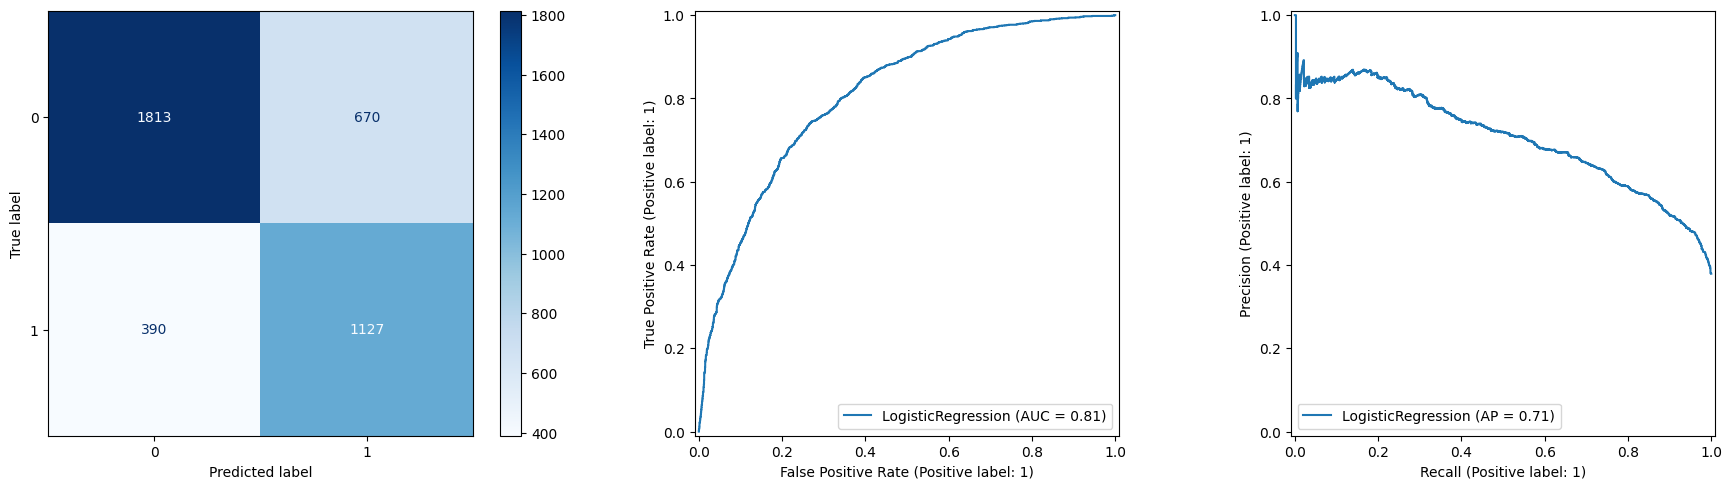

In [8]:
lr_model = LogisticRegression(C=np.float64(0.1), max_iter=500, random_state=42)
lr_model.fit(x_train_scaled, y_train)
y_pred = lr_model.predict(x_test_scaled)

# Make an 18x5 figure with 3 subplots: confusion matrix, ROC curve, and precision-recall curve.
lr_fig, lr_axes = plt.subplots(1, 3, figsize=(18, 5))

print(classification_report(y_test, y_pred))
# Confusion Matrix, ROC curve, and Precision-Recall curve.
ConfusionMatrixDisplay.from_estimator(lr_model, x_test_scaled, y_test, ax=lr_axes[0], cmap='Blues')
RocCurveDisplay.from_estimator(lr_model, x_test_scaled, y_test, ax=lr_axes[1])
PrecisionRecallDisplay.from_estimator(lr_model, x_test_scaled, y_test, ax=lr_axes[2])

plt.tight_layout()
plt.show()

## Logistic Regression Findings
TODO

## Random Forest
In here we are going to train a random forest classifier and evaluate it on the test set.

The hyperparameters used here are the best parameters found after tuning using GridSearchCV.

              precision    recall  f1-score   support

           0       0.83      0.67      0.74      2483
           1       0.59      0.77      0.67      1517

    accuracy                           0.71      4000
   macro avg       0.71      0.72      0.70      4000
weighted avg       0.74      0.71      0.71      4000



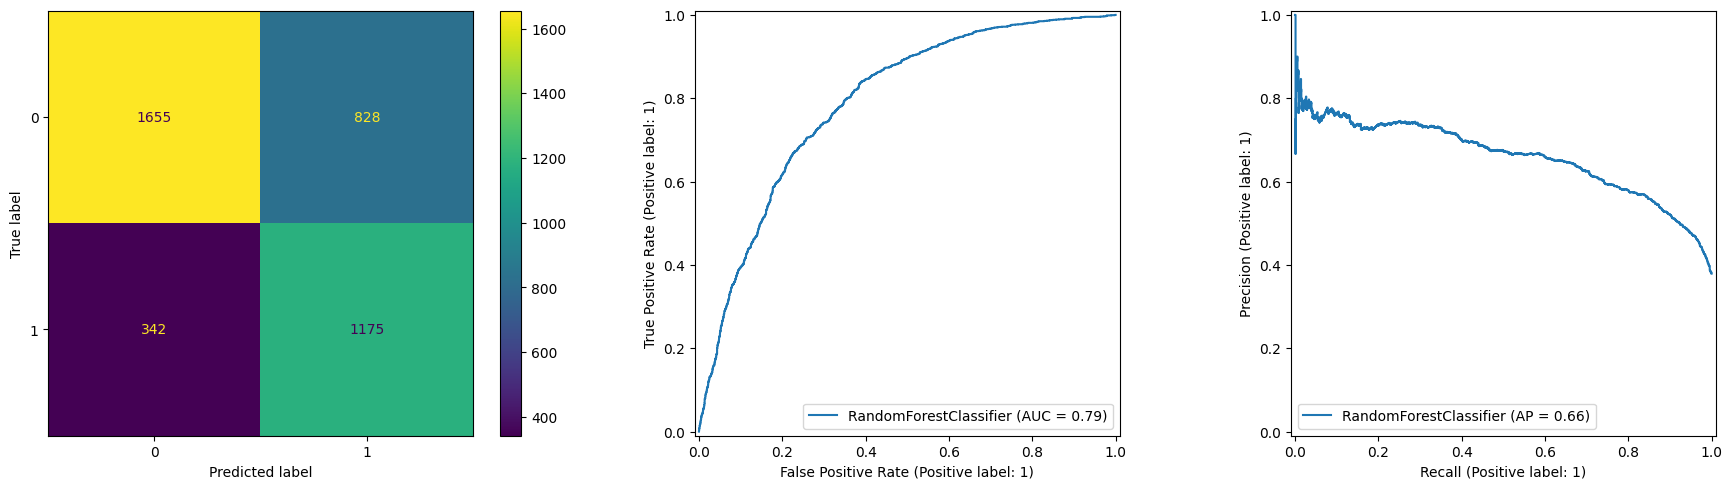

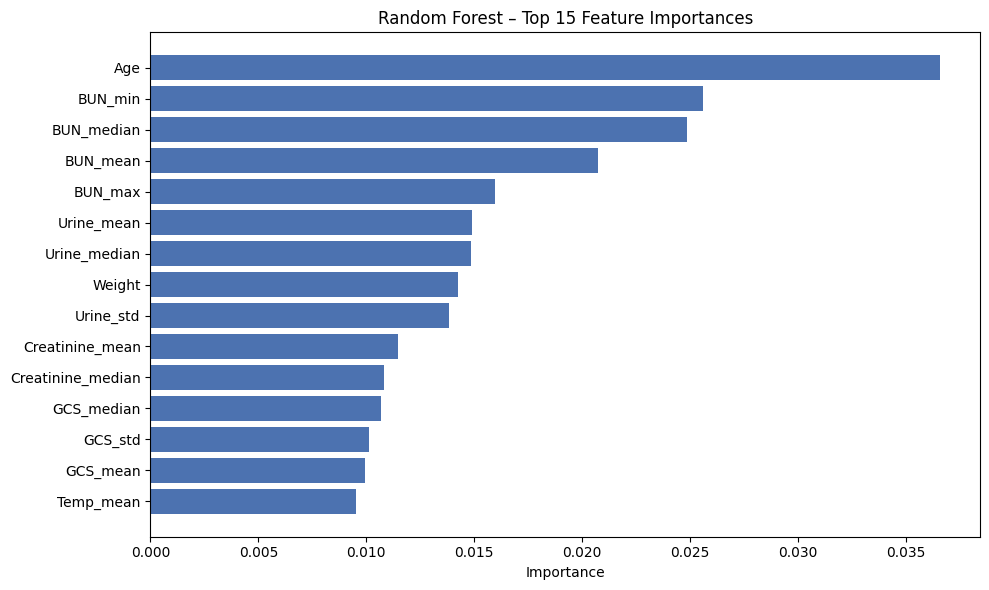

In [29]:
rf_model = RandomForestClassifier(
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=8,
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train_scaled, y_train)
y_pred = rf_model.predict(x_test_scaled)

rf_fig, rf_axes = plt.subplots(1, 3, figsize=(18, 5))

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(rf_model, x_test_scaled, y_test, ax=rf_axes[0])
RocCurveDisplay.from_estimator(rf_model, x_test_scaled, y_test, ax=rf_axes[1])
PrecisionRecallDisplay.from_estimator(rf_model, x_test_scaled, y_test, ax=rf_axes[2])
plt.tight_layout()
plt.show()

# Top 15 feature importances.
importances = pd.Series(rf_model.feature_importances_, index=df_x_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15.index, top15.values, color='#4C72B0')
ax.set_xlabel('Importance')
ax.set_title('Random Forest – Top 15 Feature Importances')
plt.tight_layout()
plt.show()

## Artificial Neural Network
Best parameters found were:
```python
{
  "model__neurons": 32, 
  "model__l2_reg": 0.001, 
  "model__dropout_rate": 0.7, 
  "epochs": 100, 
  "batch_size": 32
}
```

/Users/jeanluis.urena/.asdf/installs/python/3.12.5/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step
Final ANN test evaluation (threshold = 0.4)
              precision    recall  f1-score   support

           0       0.90      0.46      0.60      2483
           1       0.51      0.91      0.65      1517

    accuracy                           0.63      4000
   macro avg       0.70      0.68      0.63      4000
weighted avg       0.75      0.63      0.62      4000

ROC-AUC: 0.8002
Precision: 0.5062
Recall: 0.9136
Accuracy: 0.6292


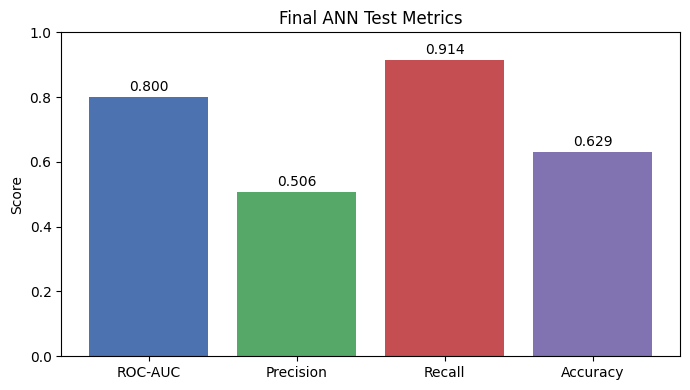

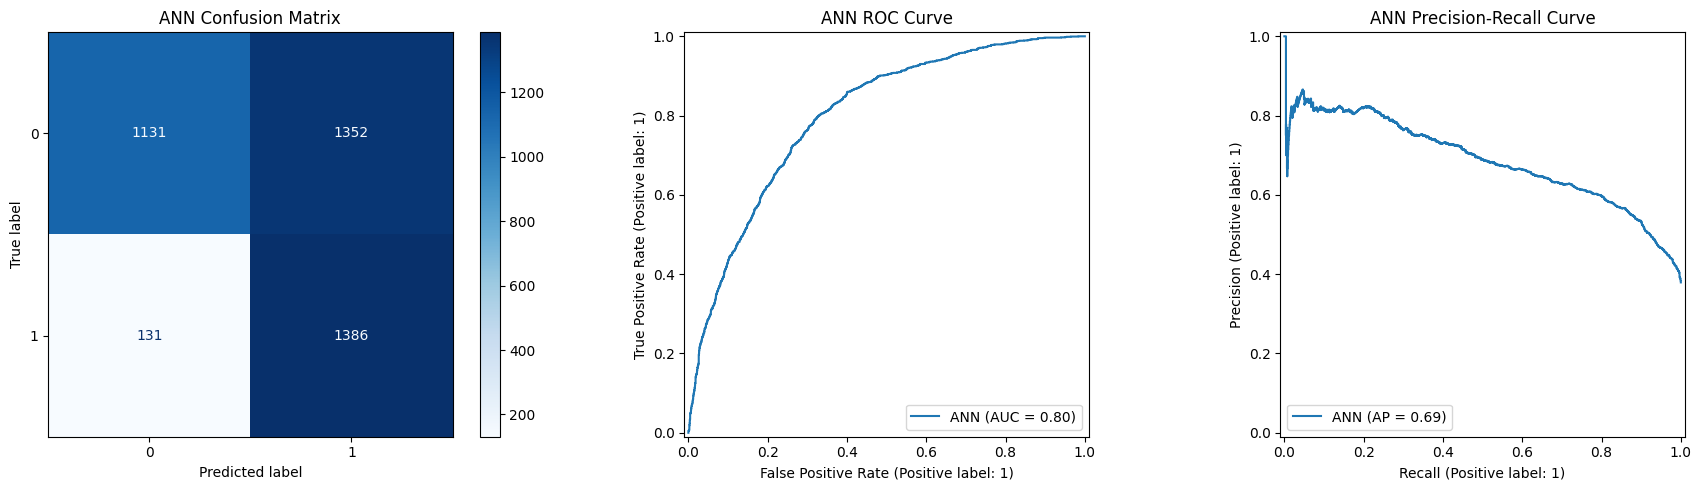

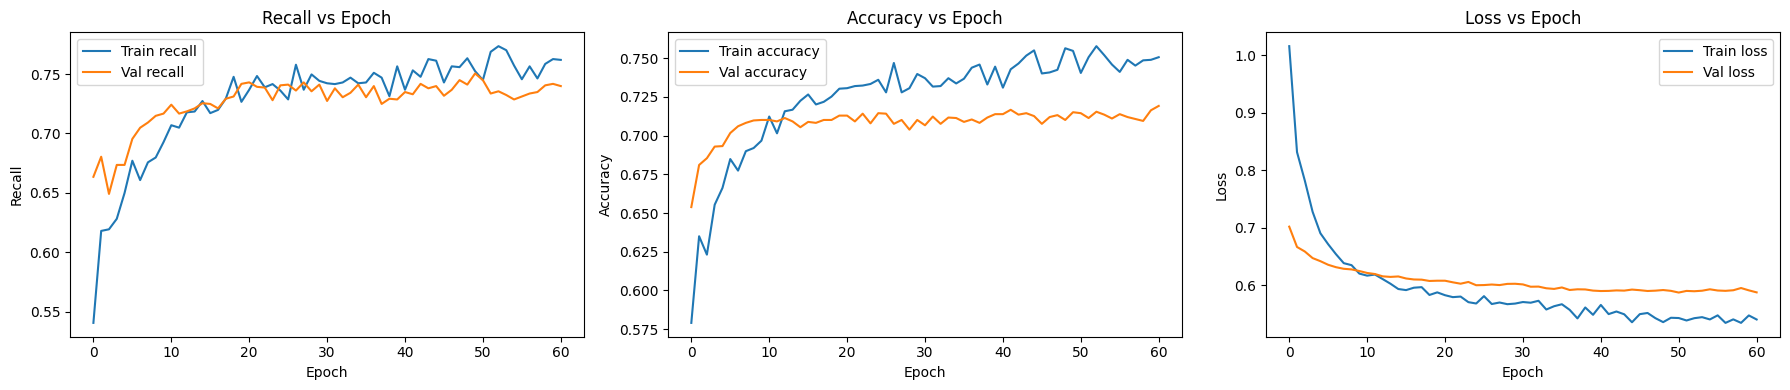

In [26]:
# ANN-specific split and scaling to avoid test leakage.
ann_scaler = StandardScaler()
x_ann_train = ann_scaler.fit_transform(df_x_train)
x_ann_val = ann_scaler.transform(df_x_val)
x_ann_test = ann_scaler.transform(df_x_test)

y_ann_train = df_y_train.values.ravel()
y_ann_val = df_y_val.values.ravel()
y_ann_test = df_y_test.values.ravel()

early_stop = EarlyStopping(patience=10, restore_best_weights=True)
ann_model = Sequential([
    Dense(32, activation='relu', input_shape=(x_ann_train.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.7),
    Dense(1, activation='sigmoid')
])
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['recall', 'precision', 'accuracy'])
history = ann_model.fit(
    x_ann_train, y_ann_train,
    validation_data=(x_ann_val, y_ann_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Predict probabilities on test set, then apply a lower threshold to prioritize recall.
y_score = ann_model.predict(x_ann_test).ravel()
y_pred = (y_score > 0.3).astype(int)

# Final test-set evaluation (single held-out evaluation).
test_roc_auc = roc_auc_score(y_ann_test, y_score)
test_precision = precision_score(y_ann_test, y_pred)
test_recall = recall_score(y_ann_test, y_pred)
test_accuracy = (y_pred == y_ann_test).mean()

print('Final ANN test evaluation (threshold = 0.4)')
print(classification_report(y_ann_test, y_pred))
print(f'ROC-AUC: {test_roc_auc:.4f}')
print(f'Precision: {test_precision:.4f}')
print(f'Recall: {test_recall:.4f}')
print(f'Accuracy: {test_accuracy:.4f}')

# Plot a compact summary of final test metrics.
metric_names = ['ROC-AUC', 'Precision', 'Recall', 'Accuracy']
metric_values = [test_roc_auc, test_precision, test_recall, test_accuracy]
plt.figure(figsize=(7, 4))
bars = plt.bar(metric_names, metric_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Final ANN Test Metrics')
for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Populate the 3-panel ANN evaluation figure.
ann_fig, ann_axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_ann_test, y_pred, ax=ann_axes[0], cmap='Blues')
ann_axes[0].set_title('ANN Confusion Matrix')
RocCurveDisplay.from_predictions(y_ann_test, y_score, ax=ann_axes[1], name='ANN')
ann_axes[1].set_title('ANN ROC Curve')
PrecisionRecallDisplay.from_predictions(y_ann_test, y_score, ax=ann_axes[2], name='ANN')
ann_axes[2].set_title('ANN Precision-Recall Curve')
plt.tight_layout()
plt.show()

# Plot Recall, Accuracy, and Loss across epochs.
fig, metric_axes = plt.subplots(1, 3, figsize=(18, 4))

metric_axes[0].plot(history.history['recall'], label='Train recall')
metric_axes[0].plot(history.history['val_recall'], label='Val recall')
metric_axes[0].set_title('Recall vs Epoch')
metric_axes[0].set_xlabel('Epoch')
metric_axes[0].set_ylabel('Recall')
metric_axes[0].legend()

metric_axes[1].plot(history.history['accuracy'], label='Train accuracy')
metric_axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
metric_axes[1].set_title('Accuracy vs Epoch')
metric_axes[1].set_xlabel('Epoch')
metric_axes[1].set_ylabel('Accuracy')
metric_axes[1].legend()

metric_axes[2].plot(history.history['loss'], label='Train loss')
metric_axes[2].plot(history.history['val_loss'], label='Val loss')
metric_axes[2].set_title('Loss vs Epoch')
metric_axes[2].set_xlabel('Epoch')
metric_axes[2].set_ylabel('Loss')
metric_axes[2].legend()

plt.tight_layout()
plt.show()

### Why Recall Prioritization?
We wanto to catch most at-risk patients. False positives are not as bad as false negatives.

- At 0.3, recall is very high. The trade off is _precision and accuracy_ .
- Moving the threshold right increases precision and accuracy but will drop recall.

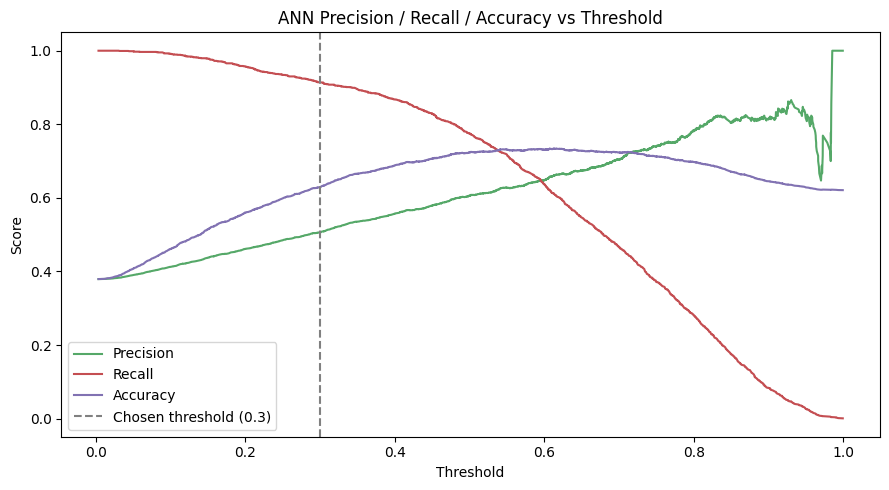

In [27]:
from sklearn.metrics import precision_recall_curve

# Sweep all thresholds derived from the model's predicted probabilities.
precisions, recalls, thresholds = precision_recall_curve(y_ann_test, y_score)
# precision_recall_curve returns len(thresholds) + 1 values for precision/recall.
# Align by dropping the last precision/recall point (which has no matching threshold).
accuracies = [
    ((y_score >= t).astype(int) == y_ann_test).mean() for t in thresholds
]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#55A868')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#C44E52')
plt.plot(thresholds, accuracies, label='Accuracy', color='#8172B2')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Chosen threshold (0.3)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('ANN Precision / Recall / Accuracy vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## Comparison Logistic Regression vs Random Forest

Text(0.5, 1.0, 'PR Curve Comparison')

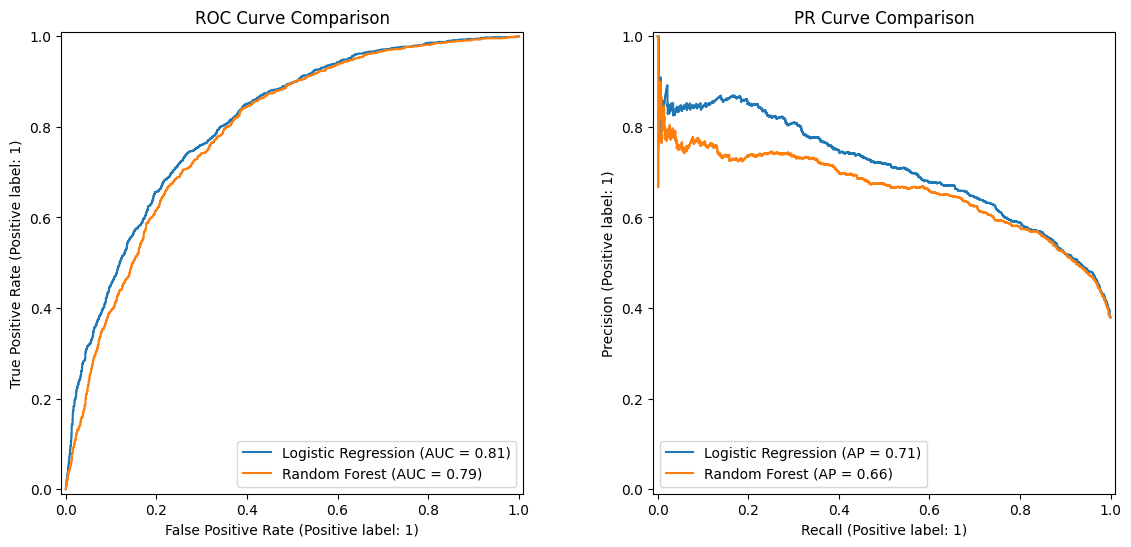

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC Curves for both on ax1
RocCurveDisplay.from_estimator(lr_model, x_test_scaled, y_test, ax=ax1, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_model, x_test_scaled, y_test, ax=ax1, name="Random Forest")
ax1.set_title("ROC Curve Comparison")

# Plot PR Curves for both on ax2
PrecisionRecallDisplay.from_estimator(lr_model, x_test_scaled, y_test, ax=ax2, name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(rf_model, x_test_scaled, y_test, ax=ax2, name="Random Forest")
ax2.set_title("PR Curve Comparison")